Daegu Apartment

<u>Business Problem</u><br>
Context: Housing needs of modern society due to limited residential land and dense business in urban areas. Apartment prices are influenced by internal and external factors. It is needed so that individuals or company can make apartment units offers and bidders can sell units on a platform by determining apartment prices since apartment owners are having difficulty in adjusting to market prices (Too high = difficult to make sales and Too low = difficult to maximize profit)

Goals: Menentukan harga sewa apartment yang tepat untuk setiap properti yang akan disewakan.

Analytic Approach: Analisis data untuk menemukan pola dan apa saja yang membedakan harga satu properti dengan properti lainnya.
Menggunakan model regresi untuk menyediakan alat memprediksi harga sewa apartment di Daegu untuk owners dan memberikan harga yang cukup adil untuk individuals dan bidders

Model: Random Forest Regressor, XGBoost, ANN Pytorch

Metric Evaluation: MAE, MSE, RMSE, R2, MAPE, CrossEntropy


 

<b> Contents </b>
1. Cleaning and Information
2. Data Preprocessing
3. Modelling
4. Conclusion
5. Recommendation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('data_daegu_apartment.csv')
df.shape

(4123, 11)

### I. Cleaning & Information
Menelaah setiap isi dari setiap column ✅, melihat apakah ada column yang missing ✅ dan mendapatkan informasi dari data dengan cara visualisasi dan statistik (distribusi data, spearman --> tukey, ANOVA, outlier)✅

In [5]:
df.info()
# Ga ada yg null, semua dtype nya udh keliatan, banyaknya sesuai dengan df.shape (4123 row, 11 column)

<class 'pandas.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   str    
 1   TimeToSubway                      4123 non-null   str    
 2   SubwayStation                     4123 non-null   str    
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 354.4 KB


In [ ]:
df.describe()
#Deskriptif statistik

,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice,LogSalePrice,age
count,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000
mean,1.930876,4.135338,2.746301,568.979141,2002.999757,5.817851,954.630851,221767.926995,12.173150,23.000243
std,2.198832,1.802640,1.496610,410.372742,8.905768,2.340507,383.805648,106739.839945,0.557027,8.905768
min,0.000000,0.000000,0.000000,0.000000,1978.000000,1.000000,135.000000,32743.000000,10.396475,11.000000
25%,0.000000,3.000000,2.000000,184.000000,1993.000000,4.000000,644.000000,144752.000000,11.882784,18.000000
50%,1.000000,5.000000,2.000000,536.000000,2006.000000,5.000000,910.000000,209734.000000,12.253600,20.000000
75%,5.000000,5.000000,4.000000,798.000000,2008.000000,7.000000,1149.000000,291150.000000,12.581597,33.000000
max,5.000000,7.000000,5.000000,1321.000000,2015.000000,10.000000,2337.000000,585840.000000,13.280804,48.000000


In [59]:
df['HallwayType'].value_counts(ascending=True)
#one-hot

HallwayType
corridor     464
mixed       1131
terraced    2528
Name: count, dtype: int64

In [7]:
df['TimeToSubway'].value_counts()
#ordinal

TimeToSubway
0-5min                1953
5min~10min             787
15min~20min            629
10min~15min            583
no_bus_stop_nearby     171
Name: count, dtype: int64

In [8]:
df['SubwayStation'].value_counts().sort_index()
#one-hot

SubwayStation
Bangoge                   502
Banwoldang                529
Chil-sung-market           74
Daegu                      65
Kyungbuk_uni_hospital    1152
Myung-duk                1044
Sin-nam                   467
no_subway_nearby          290
Name: count, dtype: int64

In [9]:
df['N_FacilitiesNearBy(ETC)'].value_counts().sort_index()
#leave as is

N_FacilitiesNearBy(ETC)
0.0    1828
1.0     631
2.0     330
5.0    1334
Name: count, dtype: int64

In [10]:
df['N_FacilitiesNearBy(PublicOffice)'].value_counts().sort_index()
#leave as is

N_FacilitiesNearBy(PublicOffice)
0.0      46
1.0     291
2.0     530
3.0     844
4.0     254
5.0    1252
6.0     451
7.0     455
Name: count, dtype: int64

In [11]:
df['N_SchoolNearBy(University)'].value_counts().sort_index()
#leave as is

N_SchoolNearBy(University)
0.0      97
1.0     833
2.0    1359
3.0     396
4.0     606
5.0     832
Name: count, dtype: int64

In [ ]:
df['N_Parkinglot(Basement)'].value_counts().sort_index()
#leave as is

N_Parkinglot(Basement)
0.0       493
18.0       51
56.0       74
76.0       51
79.0      104
108.0      50
181.0     108
184.0     139
203.0     217
218.0      41
400.0      14
475.0     203
524.0     220
536.0     664
605.0     213
798.0     502
930.0     322
1174.0    159
1270.0    420
1321.0     78
Name: count, dtype: int64

In [ ]:
df['YearBuilt'].value_counts().sort_index()
#ganti ke age

YearBuilt
1978     49
1980      4
1985     51
1986    273
1992    326
1993    451
1997     67
2003      7
2005    502
2006    460
2007    853
2008    203
2009    171
2013    322
2014    292
2015     92
Name: count, dtype: int64

In [14]:
df['N_FacilitiesInApt'].value_counts().sort_index()
#leave as is

N_FacilitiesInApt
1       41
2       50
3      477
4     1001
5      810
7      838
8      203
9      159
10     544
Name: count, dtype: int64

In [ ]:
df['Size(sqf)'].value_counts().sort_index()
#leave as is

Size(sqf)
135     19
138      2
156     16
160      1
163      1
        ..
1796    15
1928    34
2056    27
2092     8
2337    29
Name: count, Length: 89, dtype: int64

In [ ]:
df['Size(sqf)'].value_counts().head() #cari size yang paling banyak dibuat atau bisa pake df['Size(sqf)'].idxmax() atau value_counts.index[0] atau df['Size(sqf)'].value_counts().iloc[0] atau .mode()[0]

Size(sqf)
914    663
644    488
910    370
868    200
572    196
Name: count, dtype: int64

In [16]:
df['SalePrice'].value_counts().sort_index()
#pake log

SalePrice
32743     1
34070     1
34513     2
35398     4
35840     2
         ..
556637    1
557522    1
566371    2
570796    2
585840    1
Name: count, Length: 838, dtype: int64

In [77]:
df['SalePrice'].value_counts().head()

SalePrice
149274    46
168141    45
75920     41
265486    40
194690    36
Name: count, dtype: int64

#### Visualisasi untuk melihat pola
- Karena harga rumah yang sangat variatif, digunakan log1p (log(1+SalePrice)) ✅sehingga distribusi harga lebih normal, mengurangi outlier dan membuat model lebih mudah mengerti perubahan harga dengan melihat persentase dan bukan harganya secara langsung
- Menggunakan Usia dan bukan tahun agar model lebih mudah memahami (bukan angka besar) ✅
- Visualisasi dengan scatterplot untuk LogSalePrice VS Size (numeric vs numeric) ✅
- Visualisasi dengan scatterplot dengan warna sebagai size, y-label sebagai LogSalePrice dan x-lable sebagai kategori numerik lainnya ✅
- Visualisasi dengan boxplot untuk numeric vs category ✅

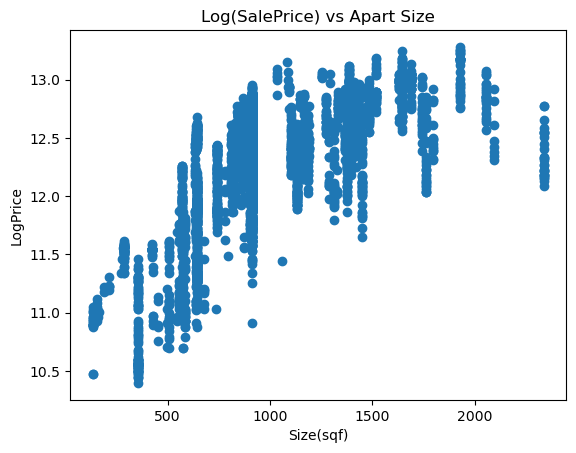

C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_26496\2582537397.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.82, 0.96])


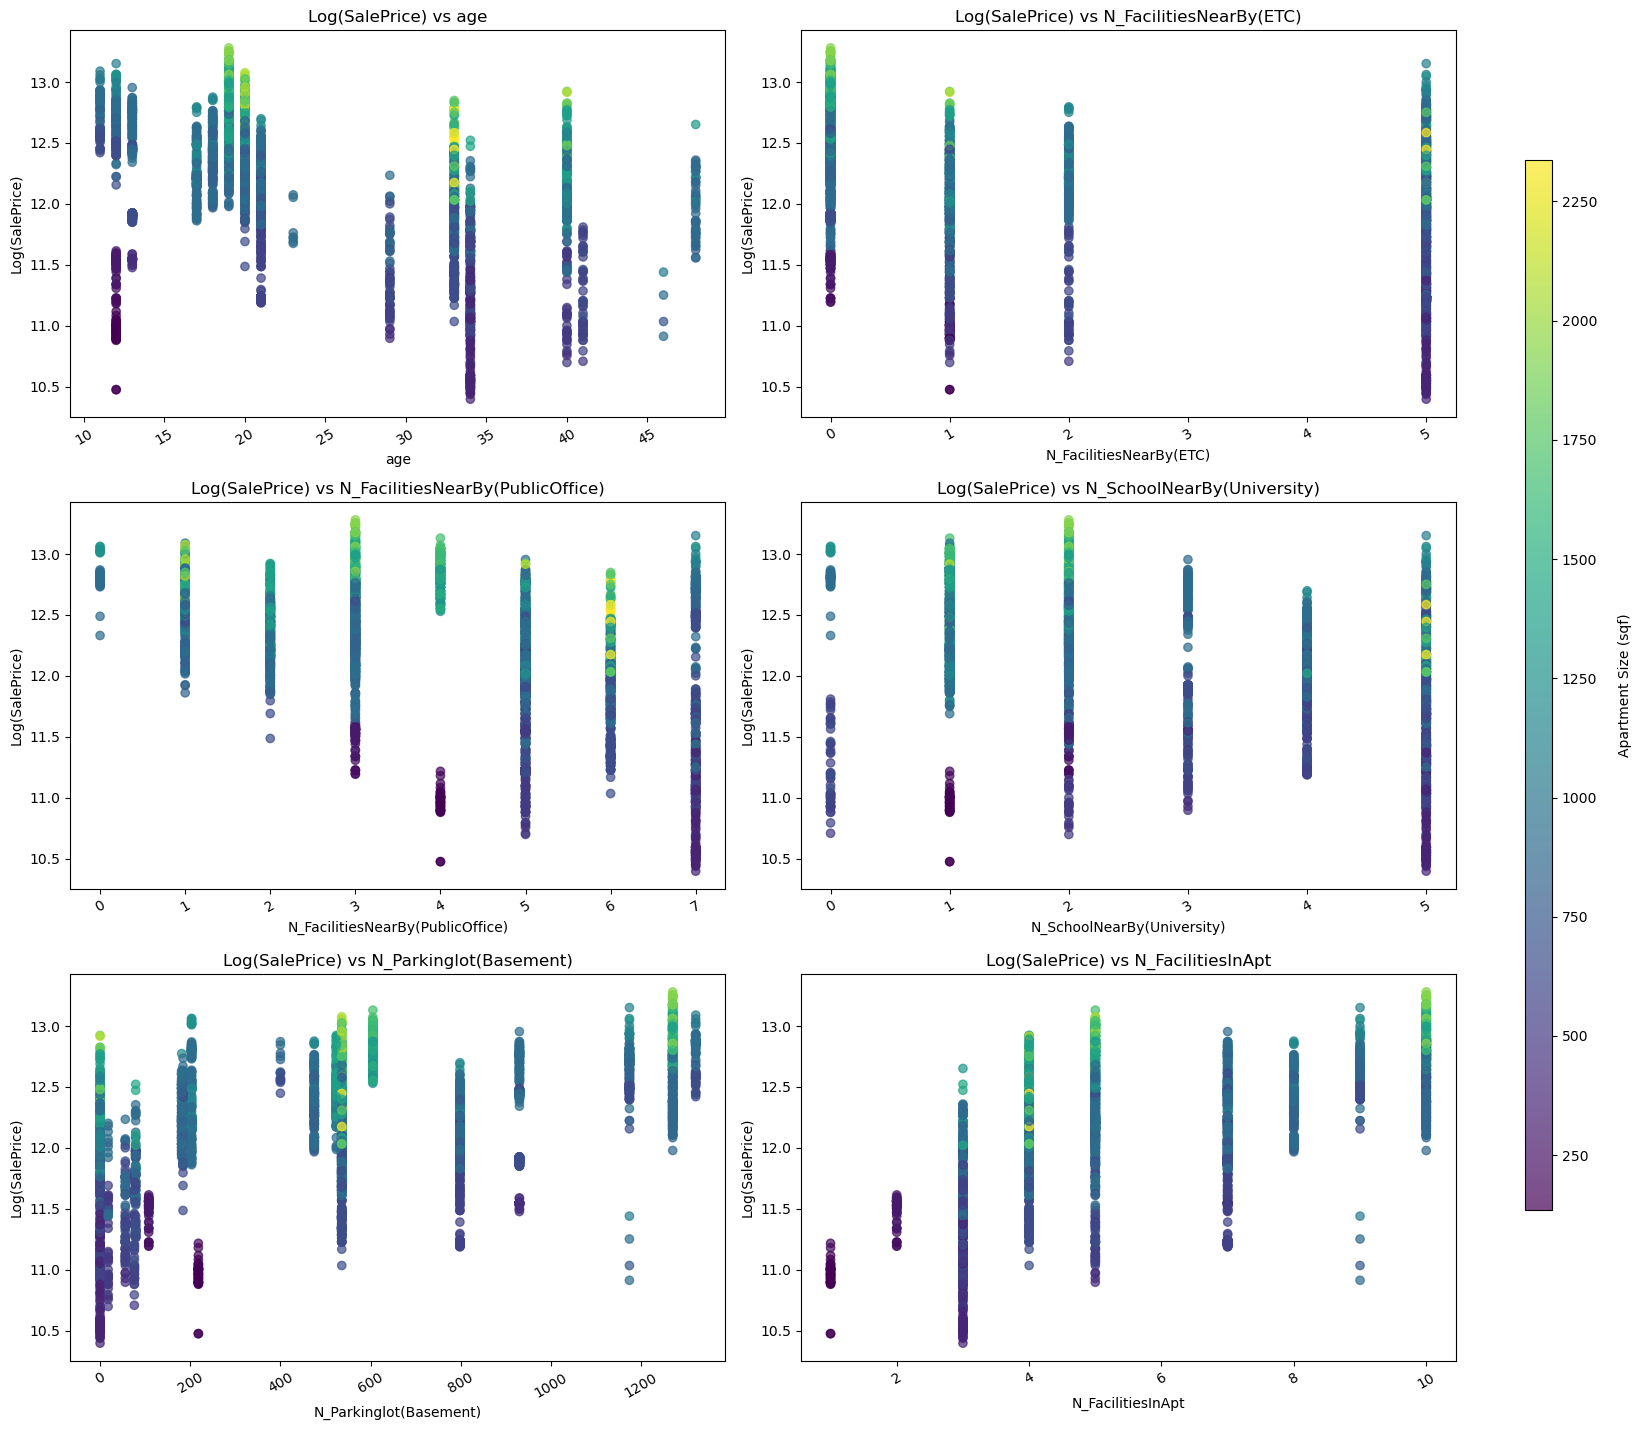

C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_26496\2582537397.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.82, 0.96])


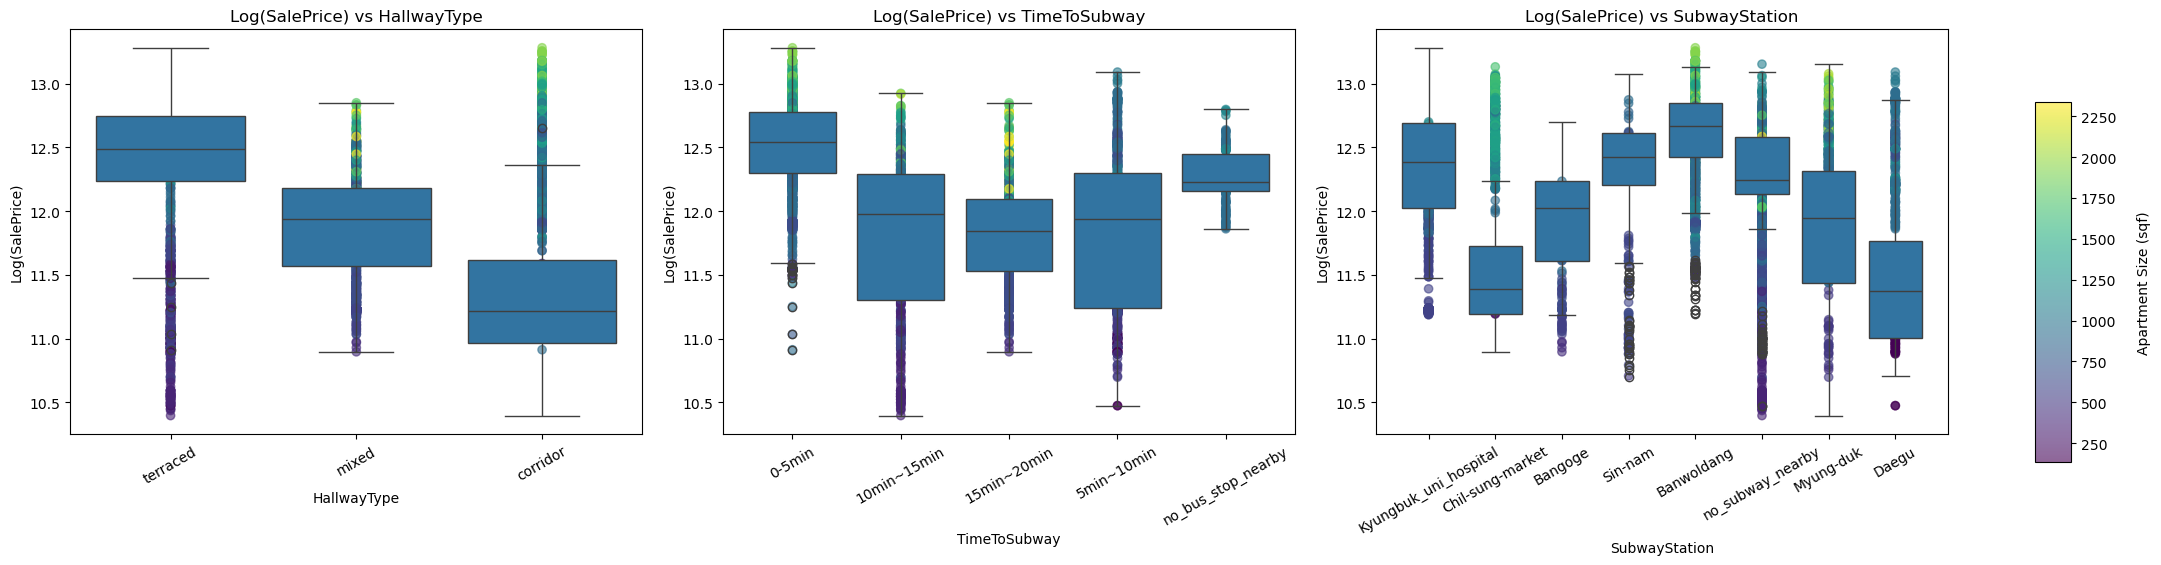

In [22]:
df['age'] = pd.Timestamp.now().year - df['YearBuilt'] # pakai pd.Timestamp.now().year supaya tidak usah ubah-ubah tahun untuk tahun berikutnya
df['LogSalePrice'] = np.log1p(df['SalePrice'])

# Price vs Size
plt.scatter(df['Size(sqf)'],df['LogSalePrice'])
plt.xlabel('Size(sqf)')
plt.ylabel('LogPrice')
plt.title('Log(SalePrice) vs Apart Size')
plt.show()

numeric_cols = [
    'age',
    'N_FacilitiesNearBy(ETC)',
    'N_FacilitiesNearBy(PublicOffice)',
    'N_SchoolNearBy(University)',
    'N_Parkinglot(Basement)',
    'N_FacilitiesInApt'
]

categorical_cols = [
    'HallwayType',
    'TimeToSubway',
    'SubwayStation'
]

# Numeric
fig, axs = plt.subplots(3, 2, figsize=(18, 15))
axs = axs.flatten()

for i, col in enumerate(numeric_cols):
    sc = axs[i].scatter(
        df[col],
        df['LogSalePrice'],
        c=df['Size(sqf)'],
        alpha=0.7
    )
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Log(SalePrice)')
    axs[i].set_title(f'Log(SalePrice) vs {col}')
    axs[i].tick_params(axis='x', rotation=30)

fig.subplots_adjust(right=0.82)
cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Apartment Size (sqf)', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.82, 0.96])
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(24, 6))

# Category
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=df[col], y=df['LogSalePrice'], ax=axs[i])

    x_codes = df[col].astype('category').cat.codes
    sc = axs[i].scatter(
        x_codes,
        df['LogSalePrice'],
        c=df['Size(sqf)'],
        alpha=0.6
    )

    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Log(SalePrice)')
    axs[i].set_title(f'Log(SalePrice) vs {col}')
    axs[i].tick_params(axis='x', rotation=30)

fig.subplots_adjust(right=0.82)
cbar_ax = fig.add_axes([0.85, 0.18, 0.015, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Apartment Size (sqf)', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.82, 0.96])
plt.show()

Di Log(SalePrice) vs Size:
- Skew ke kiri
- Harga lebih mahal kalau apart lebih besar

Di Log(SalePrice) vs Age:
-Apart yang sangat tua (>45 tahun): ukurannya cukup besar 750-1000sqf dgn harga yg masih cukup mahal
- Apart berukuran besar tidak terlalu banyak dijual dan harga nya masih mahal tetapi yg paling mahal bukan yg paling besar
- Apart <750 sqf dan 750-1000sqf banyaknya cukup seimbang
- Kebanyakan apart berukuran <750sqf masih relatif baru dengan harga yang lebih mahal
- <b> Kesimpulan: Usia Apart tidak terlalu berpengaruh terhadap harga namun cenderung apart dengan usia < 22 tahun memiliki harga yang lebih mahal </b>

Di Log(SalePrice) vs ETC
- Apart yg besar dan mahal tidak selalu memiliki fasilitas yang lebih banyak (masih cukup sama untuk semua kalangan)
- <b> Kesimpulan: Tidak terlalu menunjukkan korelasi yang bermanfaat </b>

Di Log(SalePrice) vs PublicOffice
- Apart berukuran sedang dan mahal tidak ada public office
- Apart kecil memberikan lebih banyak fasilitas public office
- <b> Kesimpulan: Tidak terlalu menunjukkan korelasi yang bermanfaat </b>

Di Log(SalePrice) vs University
- Apart yang sangat besar biasa berada di lokasi yang dikelilingi banyak universitas
- <b> Kesimpulan: Apart yang besar dan mahal cenderung berada di sekitar Universitas </b>

Di PublicOffice dan University menunjukkan beberapa apart tidak yang mahal dan ukuran sedang mungkin dimiliki bukan oleh kalangan mahasiswa atau usia produktif

Di Log(SalePrice) vs ParkingLot
- Lebih banyak apart tidak memiliki basement (lebih memilih transport station yang dekat sepertinya)
- Lebih banyak harga apart yang mahal bila memiliki parkinglot luas (premium resident sepertinya)
- <b> Kesimpulan: Parkinglot tidak terlalu menjadi masalah dalam memilih apart dan apart yang mahal cenderung memiliki parkinglot luas </b>

Di Log(SalePrice) vs FacilitiesinAPT
- Fasilitias apartment lebih menentukan kemahalan suatu apart
- <b> Kesimpulan: Lebih banyak fasilitas sangat berkolerasi dengan harga apart </b>

Di Log(SalePrice) vs HallwayType
- Apart lebih besar memiliki koridor dan mixed dengan harga yang lebih mahal dengan bias yang sangat besar
- <b> Kesimpulan: Terdapat korelasi antara tipe Hallway dengan harga apart </b>

Di Log(SalePrice) vs TimeToSubway
- Apart yang lebih besar dan mahal cukup dekat dengan Subway (<15min)
- 15-20min sangat seimbang untuk harga mahal dan murah
- Apart yang lebih kecil cenderung sangat dekat dengan subway (<10min)
- Beberapa apart menengah tidak memiliki busstop (mungkin daerah yang lebih asri)
- <b> Kesimpulan: Terdapat korelasi antara harga apart dengan dekatnya ke subway </b>

Di Log(SalePrice) vs SubwayStation
- Kawasan apart besar dan mahal berada dekat Kyungbuk_uni_hospital, Sin-nam, banwoldang dan Myung-duk
- <b> Kesimpulan: Terdapat korelasi antara SubwayStation tertentu dengan harga apart </b>

<b> Kesimpulan secara keseluruhan: Size, Subway station, Hallway, Time to Subway, Parkinglot, University, Facilities in apt dan age memiliki korelasi yang cukup besar dengan harga apart </b>

#### Melihat data secara statistik melalui distribusi dan tes parametrik untuk melihat signifikansi
- Menggunakan skew untuk melihat distribusi data ✅
- Menggunakan Korelasi Spearman untuk melihat korelasi data numerik dengan distribusi yang tidak linear ✅
    - Dilanjutkan dengan Tukey HSD untuk melihat per kategori dari column category ✅
- Menggunakan ANOVA untuk 3+ independent categoric group vs numeric ✅

In [23]:
from scipy.stats import f_oneway

# Melihat distribusi dengan skewness
print("Original SalePrice skewness:", df['SalePrice'].skew())
print("LogSalePrice skewness:", df['LogSalePrice'].skew())

#Spearman
corr_cols = numeric_cols + ['LogSalePrice', 'Size(sqf)']
corr_matrix = df[corr_cols].corr(method='spearman')
print("\nSpearman Correlation with LogSalePrice:")
print(corr_matrix['LogSalePrice'].sort_values(ascending=False))

#ANOVA
for col in ['HallwayType', 'TimeToSubway', 'SubwayStation']:
    groups = [group['LogSalePrice'].values for name, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    print(f"\n{col}:")
    print(f"F-statistic = {f_stat:.4f}")
    print(f"p-value = {p_value:.10e}")

Original SalePrice skewness: 0.4523214920387305
LogSalePrice skewness: -0.6791479057421512

Spearman Correlation with LogSalePrice:
LogSalePrice                        1.000000
Size(sqf)                           0.704138
N_FacilitiesInApt                   0.519243
N_Parkinglot(Basement)              0.433011
N_SchoolNearBy(University)         -0.392807
N_FacilitiesNearBy(PublicOffice)   -0.482899
age                                -0.494631
N_FacilitiesNearBy(ETC)            -0.506539
Name: LogSalePrice, dtype: float64

HallwayType:
F-statistic = 2434.5723
p-value = 0.0000000000e+00

TimeToSubway:
F-statistic = 556.2774
p-value = 0.0000000000e+00

SubwayStation:
F-statistic = 200.3537
p-value = 1.6297982096e-256


<b> Distribution </b>
- Hasil Skewness SalePrice = 0.45 yang menunjukkan skew ke kanan sedikit
- Hasil Skewness LogSalePrice = -0.68 yang menunjukkan skew ke kiri
<b> Kesimpulan: Menggunakan SalePrice saja lebih baik dibandingkan LogSalePrice. Kemungkinan tidak memerlukan untuk menggunakan LogSalePrice (Akan dibuktikan lewat modelling nantinya) </b>

<b> Spearman Correlation </b>
- Size = 0.704 (korelasi positif)
- Facilities in Apt = 0.519 (korelasi positif)
- Parkinglot = 0.433 (korelasi positif)
- Age = -0.495 (korelasi negatif)
- ETC = -0.507 (korelasi negatif: mungkin lingkungan lebih pedesaan?)
- Public Office = -0.483 (korelasi negatif: mungkin lebih distrik komersial, pedesaan, dll)
- Universitas = -0.393 (korelasi negatif: lebih murah untuk mahasiswa)

<b> ANOVA </b>
- Seluruh kategori memiliki hasil p<0.001 yang menunjukkan perbedaan yang signifikan secara statistik pada ketiga kategori tersebut dengan harga apart

<b> KESIMPULAN </b>
- Yang secara signifikan mempengaruhi harga apart adalah size, facilities in apt, parking lot dan age
- Semua hasil kategorik secara statistik mempengaruhi harga apart
- Perbedaan dari korelasi secara visualisasi dan statistik hanya ada pada Universitas

Dilanjut dengan Tukey HSD untuk menspesifikasikan kategori secara signifikan

In [62]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_hall = pairwise_tukeyhsd(
    endog=df['LogSalePrice'],
    groups=df['HallwayType'],
    alpha=0.05
)

tukey_time = pairwise_tukeyhsd(
    endog=df['LogSalePrice'],
    groups=df['TimeToSubway'],
    alpha=0.05
)

print(tukey_hall)
print(tukey_time)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1   group2  meandiff p-adj lower  upper  reject
-----------------------------------------------------
corridor    mixed   0.5922   0.0 0.5434 0.6409   True
corridor terraced   1.1883   0.0 1.1436 1.2329   True
   mixed terraced   0.5961   0.0 0.5645 0.6278   True
-----------------------------------------------------
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1         group2       meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
     0-5min        10min~15min     -0.7    0.0 -0.7578 -0.6422   True
     0-5min        15min~20min   -0.673    0.0 -0.7292 -0.6168   True
     0-5min         5min~10min  -0.6509    0.0 -0.7027 -0.5992   True
     0-5min no_bus_stop_nearby  -0.2443    0.0 -0.3421 -0.1466   True
10min~15min        15min~20min    0.027 0.8343 -0.0435  0.0974  False
10min~15min         5min~10min   0.0491  0.266 -0.0179   0.116

Hasil:

<b> HallwayType </b>
- Setiap tipe hallway memberikan hasil avg price yang berbeda

<b> TimeToSubway </b>
- Untuk beberapa orang dekat dengan Subway sangat penting namun lebih dari 5 menit dan tidak ada bus stop tidak terlalu menunjukkan perbedaan statistik

Subway station tidak dilakukan karena terlalu banyak

#### OUTLIERS (Boxplot & IQR)
Yang mahal dan luxurious sekali, yang murah di ujung sekali (mungkin)

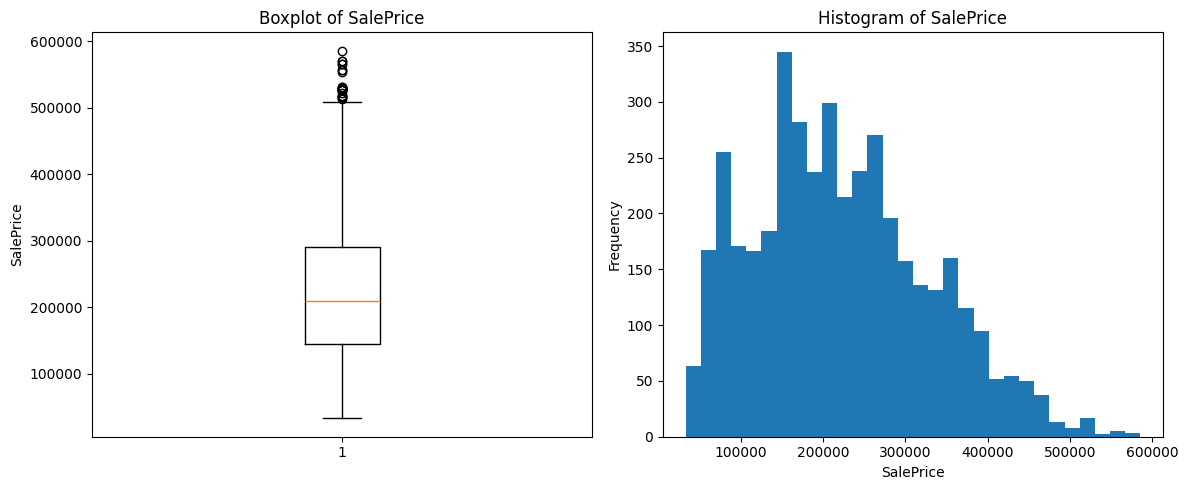

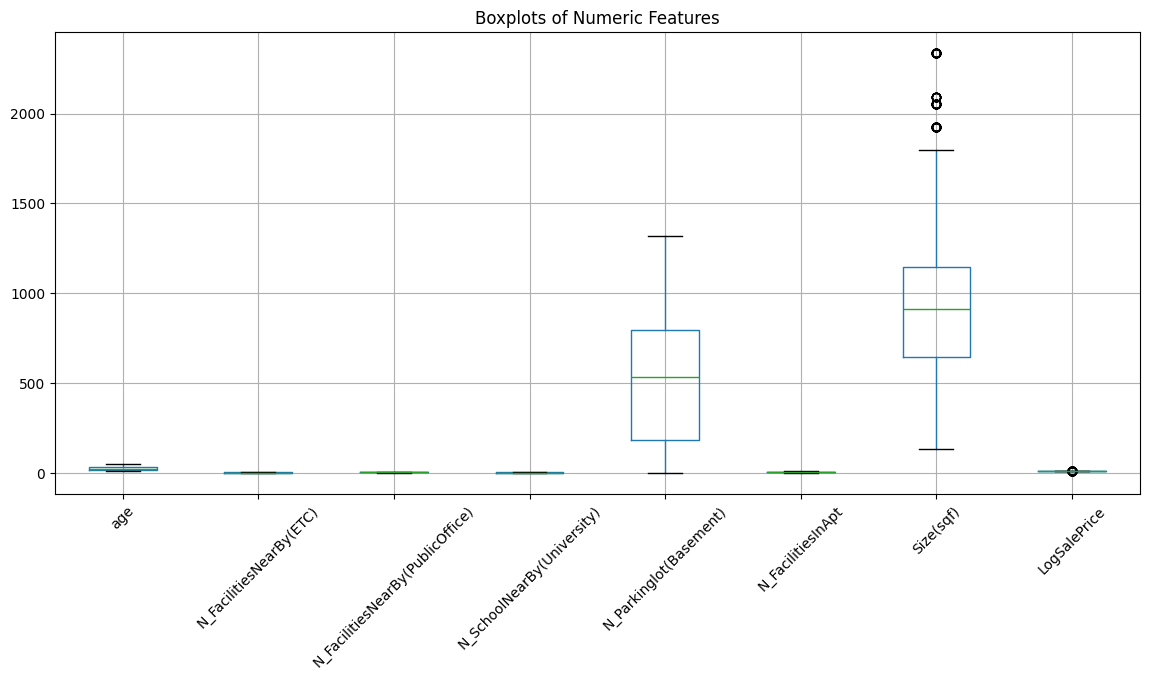

age: 0 outliers
N_FacilitiesNearBy(ETC): 0 outliers
N_FacilitiesNearBy(PublicOffice): 0 outliers
N_SchoolNearBy(University): 0 outliers
N_Parkinglot(Basement): 0 outliers
N_FacilitiesInApt: 0 outliers
Size(sqf): 98 outliers
LogSalePrice: 63 outliers


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].boxplot(df['SalePrice'])
axs[0].set_title('Boxplot of SalePrice')
axs[0].set_ylabel('SalePrice')

axs[1].hist(df['SalePrice'], bins=30)
axs[1].set_title('Histogram of SalePrice')
axs[1].set_xlabel('SalePrice')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

df[numeric_cols].boxplot(figsize=(14, 6), rot=45)
plt.title('Boxplots of Numeric Features')
plt.show()

#IQR (Interquartile Range)
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in numeric_cols:
    print(f"{col}: {count_outliers_iqr(df[col])} outliers")

Hasil: Outlier ditemukan di Size dan SalePrice dikarenakan apart yang luxurious cenderung memiliki harga yang sangat tinggi. Outliers ini tetap dipertahankan namun kemungkinan tree model menunjukkan hasil yang lebih bagus dibandingkan dengan ANN keras yang tidak di skala dengan baik dan dapat membuat error bila menggunakan RMSE

In [18]:
df.head()

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


#### II. Preprocessing:
1. Convert ke Numeric (one-hot✅, ordinal✅), log✅ dan drop yearBuilt✅ (ganti supaya lebih gampang dilihat machine)
2. Split data untuk test, validation & training + pisahin price di y dan x ga boleh ada price + batches ✅
3. Training & Test (100 data dulu): Fit pakai regression (Ridge regression/SVR Linear atau SVR rbf/Ensemble Regressor) Linear --> SVR --> RandomForestRegression/ XGBoost / Pytorch ✅
4. Pemilihan regression karena memprediksi kuantitas, dengan sample <100k dan hampir seluruh fitur penting itu dimasukan kedalam model
- https://doi.org/10.3390/analytics3010003
- https://www.mdpi.com/2076-3417/14/20/9528
- https://medium.com/analytics-vidhya/house-rental-the-data-science-way-part-2-train-a-regression-model-tpot-and-auto-ml-9cdb5cb4b1b4
4. Tambah early stopping untuk cegah overfitting kalau evaluation metrics tertentu stop improving
5. Hyperparameter pakai gridsearchCV
    - XGBoost Regressor✅: 'learning_rate':  0.1, 'n_estimators': 100, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma/min_split_loss': 5, 'random_state': 42 
    https://www.researchgate.net/publication/350810698_Prediction_of_House_Price_Using_XGBoost_Regression_Algorithm
    https://towardsdev.com/predict-house-prices-5x-faster-with-lightgbm-vs-xgboost-d5eb01ea0614
    - Random Forest Regressor✅: 'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4], 'max_features': ['sqrt', 'log2', 0.5, 0.7, 0.9, 1.0]
    https://ejournal.uin-suska.ac.id/index.php/sitekin/article/download/35804/12258
    - Pytorch✅: 'activation function': Tanh(), 'number of neurons': 16, 'hidden layers': 2, 'learning rate': 0.05, 'epochs': 410
    https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
    https://github.com/weichi21/PyTorch-Neural-network-median-house-price-prediction
6. Evaluate dgn regression metrics: MAE, MSE, RMSE, R2, MAPE, scoring prediction, MSELoss (pytorch)
- https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
- https://farshadabdulazeez.medium.com/essential-regression-evaluation-metrics-mse-rmse-mae-r%C2%B2-and-adjusted-r%C2%B2-0600daa1c03a
7. Visualisasi predicted vs actual plot, residual plot, feature importance
8. Save and LOAD

In [2]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
df['HallwayType'].value_counts()
#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

HallwayType
terraced    2528
mixed       1131
corridor     464
Name: count, dtype: int64

In [97]:
df['SubwayStation'].value_counts()

SubwayStation
Kyungbuk_uni_hospital    1152
Myung-duk                1044
Banwoldang                529
Bangoge                   502
Sin-nam                   467
no_subway_nearby          290
Chil-sung-market           74
Daegu                      65
Name: count, dtype: int64

In [27]:
#Convert numeric (one-hot = hallway, subwaystation and ordinal = timetosubway)
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #sparse_output=False to get numpy array, else return sparse matrix
onehot_encoder = onehot.fit_transform(df[['HallwayType', 'SubwayStation']]) #must be together, else overighted by the previous one

#Turn hallway_onehot and subwastation_onehot into dataframe (Hasil 2D ke table)
encoded_df = pd.DataFrame(onehot_encoder, columns=onehot.get_feature_names_out(['HallwayType', 'SubwayStation']),
                          index = df.index)

df = pd.concat([df, encoded_df], axis=1).drop(columns=['HallwayType', 'SubwayStation'])

In [28]:
df.info()
#Check!

<class 'pandas.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   TimeToSubway                         4123 non-null   str    
 1   N_FacilitiesNearBy(ETC)              4123 non-null   float64
 2   N_FacilitiesNearBy(PublicOffice)     4123 non-null   float64
 3   N_SchoolNearBy(University)           4123 non-null   float64
 4   N_Parkinglot(Basement)               4123 non-null   float64
 5   N_FacilitiesInApt                    4123 non-null   int64  
 6   Size(sqf)                            4123 non-null   int64  
 7   SalePrice                            4123 non-null   int64  
 8   age                                  4123 non-null   int64  
 9   LogSalePrice                         4123 non-null   float64
 10  HallwayType_corridor                 4123 non-null   float64
 11  HallwayType_mixed                    4123

In [29]:
ordinal = OrdinalEncoder()
df['TimeToSubway'] = ordinal.fit_transform(df[['TimeToSubway']])

- 0-5min                1953 --> 0
- 5min~10min             787 --> 3
- 15min~20min            629 --> 2
- 10min~15min            583 --> 1
- no_bus_stop_nearby     171 --> 4

In [30]:
df['TimeToSubway'].value_counts()
#Check!

TimeToSubway
0.0    1953
3.0     787
2.0     629
1.0     583
4.0     171
Name: count, dtype: int64

In [24]:
#drop yearbuilt
df = df.drop(columns=['YearBuilt'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   str    
 1   TimeToSubway                      4123 non-null   str    
 2   SubwayStation                     4123 non-null   str    
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   N_FacilitiesInApt                 4123 non-null   int64  
 8   Size(sqf)                         4123 non-null   int64  
 9   SalePrice                         4123 non-null   int64  
 10  age                               4123 non-null   int64  
 11  LogSalePrice                      4123 non-null   float64
dtypes: float64(5), in

In [31]:
#Split dataset into train, validation, test in batches (supaya cek codingnya bener atau nga dulu)
the_output_logSale = df['LogSalePrice'] #ini dulu yg digunakan
the_output_Sale = df['SalePrice']
the_datas = df.drop(['SalePrice','LogSalePrice'], axis=1)

#Split pertama: 60% training, 40% sisanya
data_train, data_sisa, hasil_train, hasil_sisa = train_test_split(the_datas, the_output_logSale, test_size = 0.4, random_state=42)

#Split kedua: 20% val, 20% test dari 40% sisanya tadi
data_val, data_test, hasil_val, hasil_test = train_test_split(data_sisa, hasil_sisa, test_size=0.5, random_state=42)

#CHECK!
print("Train:", data_train.shape, hasil_train.shape) #60% = 2473.8
print("Validation:", data_val.shape, hasil_val.shape) #20% = 824.6
print("Test:", data_test.shape, hasil_test.shape) #20% = 824.6

Train: (2473, 19) (2473,)
Validation: (825, 19) (825,)
Test: (825, 19) (825,)


In [32]:
the_datas.info()

<class 'pandas.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   TimeToSubway                         4123 non-null   float64
 1   N_FacilitiesNearBy(ETC)              4123 non-null   float64
 2   N_FacilitiesNearBy(PublicOffice)     4123 non-null   float64
 3   N_SchoolNearBy(University)           4123 non-null   float64
 4   N_Parkinglot(Basement)               4123 non-null   float64
 5   N_FacilitiesInApt                    4123 non-null   int64  
 6   Size(sqf)                            4123 non-null   int64  
 7   age                                  4123 non-null   int64  
 8   HallwayType_corridor                 4123 non-null   float64
 9   HallwayType_mixed                    4123 non-null   float64
 10  HallwayType_terraced                 4123 non-null   float64
 11  SubwayStation_Bangoge                4123

In [128]:
#Bikin batches 100 row
def batches100 (data, hasil, batch_size=100):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size], hasil[i:i+batch_size] #yield bukan return untuk 'remember where it left off' & not load all batches into memory at once

In [129]:
#Train XGB
from sklearn.exceptions import NotFittedError
modelbatchXGB = XGBRegressor(
    learning_rate = 0.1, 
    n_estimators = 10,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.6,
    gamma = 5,
    random_state = 42)

for data_batch, hasil_batch in batches100(data_train, hasil_train):
    try:
        booster = modelbatchXGB.get_booster()
    except NotFittedError:
        booster = None
    modelbatchXGB.fit(data_batch, hasil_batch, xgb_model=booster)

In [142]:
# Cek prediksi model
hasil_pred = []
hasil_asli_batch = []
for data_test_batch, hasil_test_batch in batches100(data_test, hasil_test):
    preds = modelbatchXGB.predict(data_test_batch)
    hasil_pred.extend(preds)
    hasil_asli_batch.extend(hasil_test_batch)

In [144]:
#Cek manual
for pred, asli in zip(hasil_pred[:10], hasil_asli_batch[:10]):
    print(f"Pred: {pred:.2f} | Actual: {asli}")

# Cek MAE, MAPE, R2, RMSE, MSE
mae_batchxgb = mean_absolute_error(np.expm1(hasil_asli_batch), np.expm1(hasil_pred))
mse_batchxgb = mean_squared_error(np.expm1(hasil_asli_batch), np.expm1(hasil_pred))
rmse_batchxgb = np.sqrt(mse_batchxgb)
r2_batchxgb = r2_score(np.expm1(hasil_asli_batch), np.expm1(hasil_pred))
mape_batchxgb = mean_absolute_percentage_error(np.expm1(hasil_asli_batch), np.expm1(hasil_pred))

print(f'''
MAE: {mae_batchxgb:.2f} #Predictions are off by 55569
MSE: {mse_batchxgb:.2f} #Heavily penalizing large errors
RMSE: {rmse_batchxgb:.2f} #Typical error is 73096
R2: {r2_batchxgb:.2f} #mediocre (53% of price variation)
MAPE: {mape_batchxgb:.2f} #predictions are off by 27%
''')

Pred: 12.27 | Actual: 11.950328420169882
Pred: 12.13 | Actual: 11.87313515432909
Pred: 11.48 | Actual: 11.103030559782677
Pred: 12.13 | Actual: 11.727181640294528
Pred: 12.33 | Actual: 12.005894606470704
Pred: 11.60 | Actual: 11.472290952874046
Pred: 12.27 | Actual: 11.87313515432909
Pred: 11.85 | Actual: 11.439504948772196
Pred: 12.13 | Actual: 11.950328420169882
Pred: 11.54 | Actual: 10.959940146806769

MAE: 55569.72 #Predictions are off by 55569
MSE: 5343101150.34 #Heavily penalizing large errors
RMSE: 73096.52 #Typical error is 73096
R2: 0.53 #mediocre (53% of price variation)
MAPE: 0.27 #predictions are off by 27%



#### III. Modelling
<b> XGBoost </b>

In [158]:
# FUll Dataset XGB
modelXGB = XGBRegressor(
    learning_rate=0.1, 
    n_estimators=100,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.6,
    gamma=5,
    random_state=42
)

modelXGB.fit(data_train, hasil_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [159]:
# Predict modelXGB dengan data val
hasil_predXGB = modelXGB.predict(data_val)

In [160]:
#Evaluate
modelXGB.score(data_val, hasil_val)

0.7875851320822003

In [ ]:
#Evaluate metrics XGB
hasil_val_pred_nontuned = np.expm1(modelXGB.predict(data_val))
hasil_val_nonlog_nontuned = np.expm1(hasil_val)

print(f'''--VAL METRICS--
MAE: {mean_absolute_error(hasil_val_nonlog_nontuned, hasil_val_pred_nontuned):.2f}
RMSE: {np.sqrt(mean_squared_error(hasil_val_nonlog_nontuned, hasil_val_pred_nontuned)):.2f}
R2: {r2_score(hasil_val_nonlog_nontuned, hasil_val_pred_nontuned):.2f}
MAPE: {mean_absolute_percentage_error(hasil_val_nonlog_nontuned, hasil_val_pred_nontuned):.2f}
''')

--VAL METRICS--
MAE: 40268.98
RMSE: 50775.55
R2: 0.75
MAPE: 0.21



In [65]:
#Hyperparameter tuning
modelXGB_tuned = XGBRegressor(
    learning_rate=0.05, #lowered for more careful learning steps
    n_estimators=1000, #more trees that's why early stopped is added
    max_depth=4, #shallower to reduce overfit
    subsample=0.8, #no changes
    colsample_bytree=0.8, #increased for more features per tree
    gamma=0.1, #reduced (blocking most splits)
    min_child_weight=5, #for small dataset
    reg_alpha=0.1, #L1 regularization
    reg_lambda=1.0, #L2 regularization
    early_stopping_rounds=50, #stop when no improvements
    random_state=42
)

modelXGB_tuned.fit(data_train, hasil_train,
             eval_set=[(data_train, hasil_train), (data_val, hasil_val)],
             verbose=100)
print(f"Best iteration: {modelXGB_tuned.best_iteration}")

[0]	validation_0-rmse:0.54341	validation_1-rmse:0.52385
[100]	validation_0-rmse:0.21752	validation_1-rmse:0.22459
[200]	validation_0-rmse:0.21707	validation_1-rmse:0.22412
[220]	validation_0-rmse:0.21701	validation_1-rmse:0.22415
Best iteration: 170


In [66]:
#Evaluate metrics
hasil_val_pred = np.expm1(modelXGB_tuned.predict(data_val))
hasil_val_nonlog = np.expm1(hasil_val)

print(f'''--VAL METRICS--
MAE: {mean_absolute_error(hasil_val_nonlog, hasil_val_pred):.2f}
RMSE: {np.sqrt(mean_squared_error(hasil_val_nonlog, hasil_val_pred)):.2f}
R2: {r2_score(hasil_val_nonlog, hasil_val_pred):.2f}
MAPE: {mean_absolute_percentage_error(hasil_val_nonlog, hasil_val_pred):.2f}
''')

--VAL METRICS--
MAE: 33996.28
RMSE: 43503.16
R2: 0.82
MAPE: 0.18



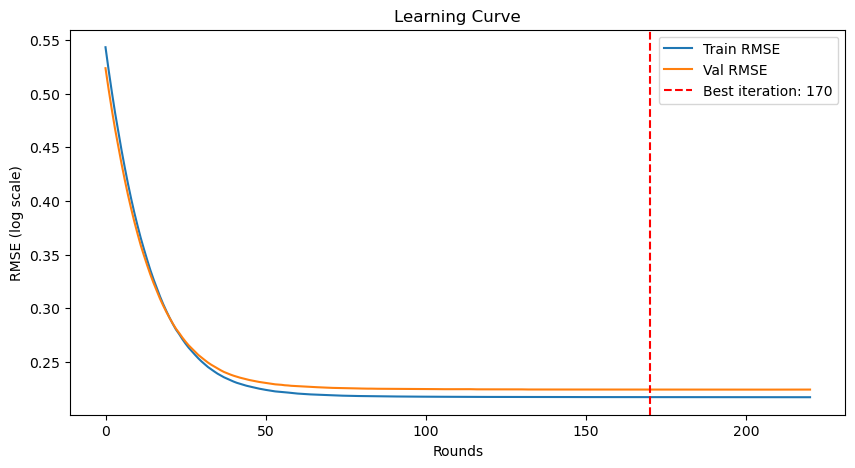

Train RMSE: 0.2171
Val RMSE:   0.2241
Gap:        0.0070


In [67]:
evalsXGB_tuned = modelXGB_tuned.evals_result()
train_rmse = evalsXGB_tuned['validation_0']['rmse']
val_rmse   = evalsXGB_tuned['validation_1']['rmse']

plt.figure(figsize=(10,5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Val RMSE')
plt.axvline(x=modelXGB_tuned.best_iteration, 
            color='red', linestyle='--', 
            label=f'Best iteration: {modelXGB_tuned.best_iteration}')
plt.xlabel('Rounds')
plt.ylabel('RMSE (log scale)')
plt.legend()
plt.title('Learning Curve')
plt.show()

final_train = train_rmse[modelXGB_tuned.best_iteration]
final_val   = val_rmse[modelXGB_tuned.best_iteration]
print(f"Train RMSE: {final_train:.4f}")
print(f"Val RMSE:   {final_val:.4f}")
print(f"Gap:        {final_val - final_train:.4f}")

Pada round 50, kedua hasil mulai landai --> hyperparameter sudah cukup baik. tinggal memberikan model lebih banyak data

In [69]:
#Test modelXGB_tuned
hasil_test_pred = np.expm1(modelXGB_tuned.predict(data_test))
hasil_test_nonlog = np.expm1(hasil_test)

mae_xgb = mean_absolute_error(hasil_test_nonlog, hasil_test_pred)
rmse_xgb = np.sqrt(mean_squared_error(hasil_test_nonlog, hasil_test_pred))
r2_xgb = r2_score(hasil_test_nonlog, hasil_test_pred)
mape_xgb = mean_absolute_percentage_error(hasil_test_nonlog, hasil_test_pred)

print(f'''--TEST METRICS--
MAE: {mae_xgb:.2f}
RMSE: {rmse_xgb:.2f}
R2: {r2_xgb:.2f}
MAPE: {mape_xgb:.2f}
''')

--TEST METRICS--
MAE: 32833.87
RMSE: 42111.69
R2: 0.85
MAPE: 0.17



In [ ]:
#Coba pakai the_output_Sale
#Split pertama: 80% training, 20% test
data_train_Sale, data_test_Sale, hasil_train_Sale, hasil_test_Sale = train_test_split(the_datas, the_output_Sale, test_size = 0.2, random_state=42)

#CHECK!
print("Train:", data_train_Sale.shape, hasil_train_Sale.shape) #80% = 3298.2
print("Test:", data_test_Sale.shape, hasil_test_Sale.shape) #20% = 824.6

modelXGB_tuned_Sale = XGBRegressor(
    learning_rate=0.05, 
    n_estimators=1000, 
    max_depth=4, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    gamma=0.1, 
    min_child_weight=5, 
    reg_alpha=0.1, 
    reg_lambda=1.0, 
    early_stopping_rounds=50, 
    random_state=42
)

modelXGB_tuned_Sale.fit(data_train_Sale, hasil_train_Sale,
             eval_set=[(data_train_Sale, hasil_train_Sale)],
             verbose=100)
print(f"Best iteration: {modelXGB_tuned_Sale.best_iteration}")

Train: (3298, 19) (3298,)
Test: (825, 19) (825,)
[0]	validation_0-rmse:103307.28308
[100]	validation_0-rmse:42567.99784
[200]	validation_0-rmse:42275.63620
[300]	validation_0-rmse:42193.79064
[400]	validation_0-rmse:42143.98205
[500]	validation_0-rmse:42124.39899
[600]	validation_0-rmse:42108.35163
[700]	validation_0-rmse:42100.98085
[800]	validation_0-rmse:42094.08901
[900]	validation_0-rmse:42089.49739
[999]	validation_0-rmse:42087.09265
Best iteration: 965


In [ ]:
#Evaluate metrics the_Output_Sale
hasil_test_pred_Sale = modelXGB_tuned_Sale.predict(data_test)

print(f'''--TEST METRICS--
MAE: {mean_absolute_error(hasil_test_Sale, hasil_test_pred_Sale):.2f}
RMSE: {np.sqrt(mean_squared_error(hasil_test_Sale, hasil_test_pred_Sale)):.2f}
R2: {r2_score(hasil_test_Sale, hasil_test_pred_Sale):.2f}
MAPE: {mean_absolute_percentage_error(hasil_test_Sale, hasil_test_pred_Sale):.2f}
''')

--TEST METRICS--
MAE: 32104.06
RMSE: 41031.16
R2: 0.84
MAPE: 0.18



In [99]:
#Cobain Model XGB
example_apart = pd.DataFrame({
    'TimeToSubway': [1.0],
    'N_FacilitiesNearBy(ETC)' : [2.0],
    'N_FacilitiesNearBy(PublicOffice)': [5.0],
    'N_SchoolNearBy(University)' : [5.0],
    'N_Parkinglot(Basement)' : [2.0],
    'N_FacilitiesInApt' : [2],
    'Size(sqf)' : [150],
    'age': [10],
    'HallwayType_corridor': [0.0],
    'HallwayType_mixed': [0.0],
    'HallwayType_terraced': [1.0], 
    'SubwayStation_Bangoge': [0.0],
    'SubwayStation_Banwoldang': [0.0],
    'SubwayStation_Chil-sung-market': [0.0],
    'SubwayStation_Daegu': [1.0],
    'SubwayStation_Kyungbuk_uni_hospital': [0.0],
    'SubwayStation_Myung-duk': [0.0],
    'SubwayStation_Sin-nam': [0.0],
    'SubwayStation_no_subway_nearby': [0.0],})
print(example_apart.shape)
example_predXGB = np.expm1(modelXGB_tuned.predict(example_apart))
print(f'Predictedprice: {example_predXGB}')

(1, 19)
Predictedprice: [115695.4]


#### III. Modelling
<b> RandomForest </b>

In [34]:
#Split pertama: 80% training, 20% sisanya
dataRF_train, dataRF_test, hasilRF_train, hasilRF_test = train_test_split(the_datas, the_output_logSale, test_size = 0.2, random_state=42)

#CHECK!
print("Train:", dataRF_train.shape, hasilRF_train.shape) #80% = 3298.4
print("Test:", dataRF_test.shape, hasilRF_test.shape) #20% = 824.6

Train: (3298, 19) (3298,)
Test: (825, 19) (825,)


In [98]:
modelRF = RandomForestRegressor(random_state=42)
grid_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 0.9, 1.0]
}
modelRF_grid = GridSearchCV(modelRF, grid_param, cv=5, scoring='r2', verbose=2)

modelRF_grid.fit(dataRF_train, hasilRF_train)

print(f'''Best param: {modelRF_grid.best_params_}
Best CV R2: {modelRF_grid.best_score_}
Best RF: {modelRF_grid.best_estimator_}''')

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

In [100]:
#Evaluate modelRF_grid
bestRF = modelRF_grid.best_estimator_
hasilRF_pred = np.expm1(bestRF.predict(dataRF_test))
hasilRF_asli = np.expm1(hasilRF_test)
modelRF_grid.score(dataRF_test, hasilRF_test)

0.8420002458610006

In [101]:
mae_RF = mean_absolute_error(hasilRF_asli, hasilRF_pred)
rmse_RF = np.sqrt(mean_squared_error(hasilRF_asli, hasilRF_pred))
r2_RF = r2_score(hasilRF_asli, hasilRF_pred)
mape_RF = mean_absolute_percentage_error(hasilRF_asli, hasilRF_pred)

print(f'''--TEST METRICS--
MAE: {mae_RF:.2f}
RMSE: {rmse_RF:.2f}
R2: {r2_RF:.2f}
MAPE: {mape_RF:.2f}
''')

--TEST METRICS--
MAE: 31532.61
RMSE: 41120.30
R2: 0.84
MAPE: 0.17



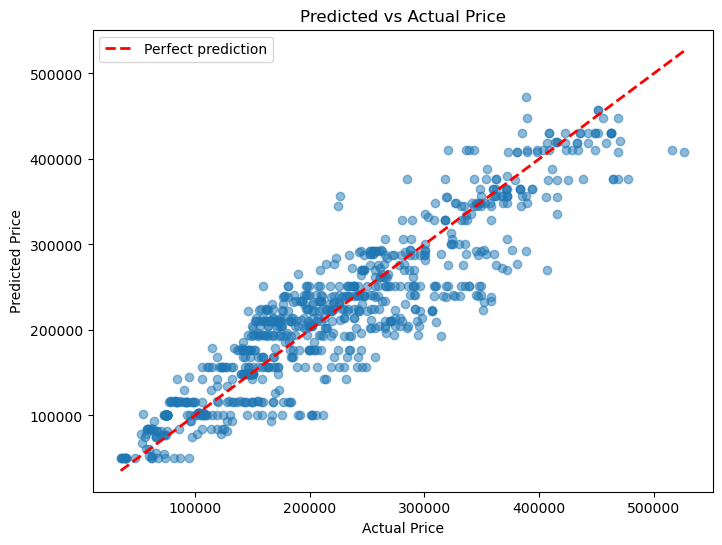

In [102]:
#Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(hasilRF_asli, hasilRF_pred, alpha=0.5)
plt.plot([hasilRF_asli.min(), hasilRF_asli.max()],
         [hasilRF_asli.min(), hasilRF_asli.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Price')
plt.legend()
plt.show()

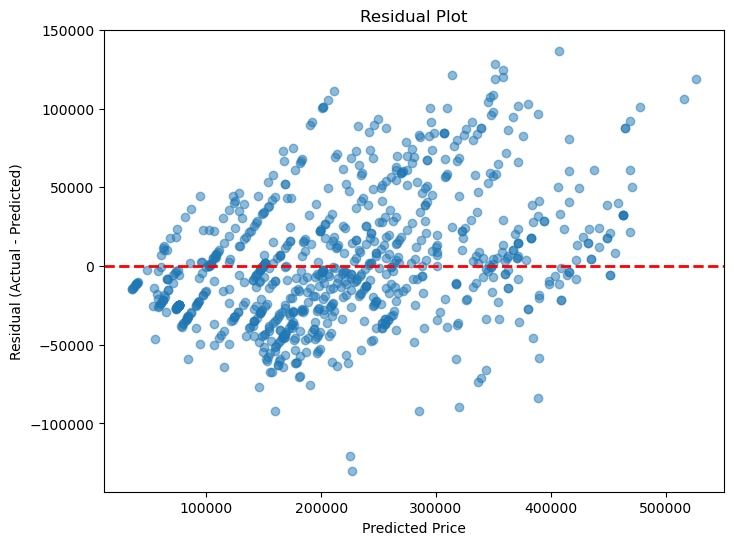

In [103]:
#Plot residuals
residuals = hasilRF_asli - hasilRF_pred

plt.figure(figsize=(8,6))
plt.scatter(hasilRF_asli, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [110]:
#Cobain Model RF
example_apart = pd.DataFrame({
    'TimeToSubway': [1.0],
    'N_FacilitiesNearBy(ETC)' : [2.0],
    'N_FacilitiesNearBy(PublicOffice)': [5.0],
    'N_SchoolNearBy(University)' : [5.0],
    'N_Parkinglot(Basement)' : [2.0],
    'N_FacilitiesInApt' : [2],
    'Size(sqf)' : [150],
    'age': [10],
    'HallwayType_corridor': [0.0],
    'HallwayType_mixed': [0.0],
    'HallwayType_terraced': [1.0], 
    'SubwayStation_Bangoge': [0.0],
    'SubwayStation_Banwoldang': [0.0],
    'SubwayStation_Chil-sung-market': [0.0],
    'SubwayStation_Daegu': [1.0],
    'SubwayStation_Kyungbuk_uni_hospital': [0.0],
    'SubwayStation_Myung-duk': [0.0],
    'SubwayStation_Sin-nam': [0.0],
    'SubwayStation_no_subway_nearby': [0.0],})
print(example_apart.shape)
example_predRF = np.round(np.expm1(bestRF.predict(example_apart)), 2)
print(f'Predictedprice: {example_predRF}')

(1, 19)
Predictedprice: [237906.25]


#### III. Modelling
<b> Pytorch NN </b>

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [89]:
scaler = StandardScaler()
data_traintorch = scaler.fit_transform(dataRF_train)
data_testtorch = scaler.transform(dataRF_test)

#Check!
print(f'''Train data scaled: {data_traintorch.shape}
Test data scaled: {data_testtorch.shape}
{data_traintorch} {data_testtorch}''')

Train data scaled: (3298, 19)
Test data scaled: (825, 19)
[[ 0.61730265  1.40331854  1.03795646 ...  1.71884742 -0.35602098
  -0.28140448]
 [-0.90256607 -0.87363932 -0.07274451 ... -0.58178521 -0.35602098
  -0.28140448]
 [ 0.61730265  1.40331854  1.03795646 ...  1.71884742 -0.35602098
  -0.28140448]
 ...
 [ 1.37723702  1.40331854  0.48260597 ... -0.58178521 -0.35602098
  -0.28140448]
 [ 0.61730265  1.40331854  1.03795646 ...  1.71884742 -0.35602098
  -0.28140448]
 [ 1.37723702  1.40331854  0.48260597 ... -0.58178521 -0.35602098
  -0.28140448]] [[-0.90256607 -0.87363932  0.48260597 ... -0.58178521 -0.35602098
  -0.28140448]
 [-0.14263171 -0.41824775  0.48260597 ... -0.58178521 -0.35602098
  -0.28140448]
 [ 1.37723702  0.03714382  0.48260597 ... -0.58178521 -0.35602098
  -0.28140448]
 ...
 [ 0.61730265 -0.41824775  0.48260597 ...  1.71884742 -0.35602098
  -0.28140448]
 [-0.14263171 -0.41824775 -1.18344549 ... -0.58178521 -0.35602098
  -0.28140448]
 [-0.90256607 -0.87363932  0.48260597 ..

In [90]:
#Ubah jadi tensor
data_traintensor = torch.FloatTensor(data_traintorch)
hasil_traintensor = torch.FloatTensor(hasilRF_train).reshape(-1,1)
data_testtensor = torch.FloatTensor(data_testtorch)
hasil_testtensor = torch.FloatTensor(np.array(hasilRF_test)).reshape(-1,1)

print(f'''Datatrain: {data_traintensor}
Hasiltrain: {hasil_traintensor}
Datatest: {data_testtensor}
Hasiltest: {hasil_testtensor}''')

Datatrain: tensor([[ 0.6173,  1.4033,  1.0380,  ...,  1.7188, -0.3560, -0.2814],
        [-0.9026, -0.8736, -0.0727,  ..., -0.5818, -0.3560, -0.2814],
        [ 0.6173,  1.4033,  1.0380,  ...,  1.7188, -0.3560, -0.2814],
        ...,
        [ 1.3772,  1.4033,  0.4826,  ..., -0.5818, -0.3560, -0.2814],
        [ 0.6173,  1.4033,  1.0380,  ...,  1.7188, -0.3560, -0.2814],
        [ 1.3772,  1.4033,  0.4826,  ..., -0.5818, -0.3560, -0.2814]])
Hasiltrain: tensor([[12.2662],
        [12.7870],
        [12.0585],
        ...,
        [12.4826],
        [12.1085],
        [12.2149]])
Datatest: tensor([[-0.9026, -0.8736,  0.4826,  ..., -0.5818, -0.3560, -0.2814],
        [-0.1426, -0.4182,  0.4826,  ..., -0.5818, -0.3560, -0.2814],
        [ 1.3772,  0.0371,  0.4826,  ..., -0.5818, -0.3560, -0.2814],
        ...,
        [ 0.6173, -0.4182,  0.4826,  ...,  1.7188, -0.3560, -0.2814],
        [-0.1426, -0.4182, -1.1834,  ..., -0.5818, -0.3560, -0.2814],
        [-0.9026, -0.8736,  0.4826,  ..., 

In [91]:
#Model
input_dim = data_traintensor.shape[1]

# 'activation function': Tanh(), 'number of neurons': 16, 'hidden layers': 2, 'learning rate': 0.01, 'epochs': 410
model_nn = nn.Sequential(
    nn.Linear(input_dim, 16),
    nn.Tanh(),
    nn.Linear(16,16),
    nn.Tanh(),
    nn.Linear(16,1)
)

optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [92]:
#Train the NN model
train_losses = []
for epoch in range(3000):
    model_nn.train()
    optimizer.zero_grad()
    preds = model_nn(data_traintensor)
    loss = criterion(preds, hasil_traintensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if epoch %50==0:
        print(f'Epoch: {epoch}/3000 | Loss: {loss.item():.4f}')

Epoch: 0/3000 | Loss: 148.0497
Epoch: 50/3000 | Loss: 6.0823
Epoch: 100/3000 | Loss: 0.1292
Epoch: 150/3000 | Loss: 0.1083
Epoch: 200/3000 | Loss: 0.1036
Epoch: 250/3000 | Loss: 0.0967
Epoch: 300/3000 | Loss: 0.0817
Epoch: 350/3000 | Loss: 0.0773
Epoch: 400/3000 | Loss: 0.0747
Epoch: 450/3000 | Loss: 0.0729
Epoch: 500/3000 | Loss: 0.0715
Epoch: 550/3000 | Loss: 0.0705
Epoch: 600/3000 | Loss: 0.0700
Epoch: 650/3000 | Loss: 0.0696
Epoch: 700/3000 | Loss: 0.0693
Epoch: 750/3000 | Loss: 0.0690
Epoch: 800/3000 | Loss: 0.0685
Epoch: 850/3000 | Loss: 0.0678
Epoch: 900/3000 | Loss: 0.0651
Epoch: 950/3000 | Loss: 0.0615
Epoch: 1000/3000 | Loss: 0.0602
Epoch: 1050/3000 | Loss: 0.0576
Epoch: 1100/3000 | Loss: 0.0558
Epoch: 1150/3000 | Loss: 0.0554
Epoch: 1200/3000 | Loss: 0.0544
Epoch: 1250/3000 | Loss: 0.0505
Epoch: 1300/3000 | Loss: 0.0492
Epoch: 1350/3000 | Loss: 0.0487
Epoch: 1400/3000 | Loss: 0.0485
Epoch: 1450/3000 | Loss: 0.0483
Epoch: 1500/3000 | Loss: 0.0482
Epoch: 1550/3000 | Loss: 0.04

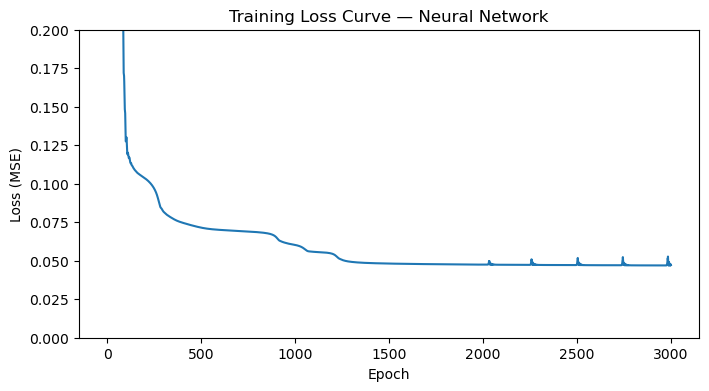

In [93]:
#Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.ylim(0,0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Curve — Neural Network')
plt.show()

In [94]:
#Evaluate
model_nn.eval()
with torch.no_grad():
    hasil_predNN = model_nn(data_testtensor).numpy().flatten()

hasil_predNN_nonlog = np.expm1(hasil_predNN)
hasil_testNN = np.expm1(hasil_testtensor)

mae_NN = mean_absolute_error(hasil_testNN, hasil_predNN_nonlog)
rmse_NN = np.sqrt(mean_squared_error(hasil_testNN, hasil_predNN_nonlog))
r2_NN = r2_score(hasil_testNN, hasil_predNN_nonlog)
mape_NN = mean_absolute_percentage_error(hasil_testNN, hasil_predNN_nonlog)

print(f'''--NN Test Metrics--
MAE: {mae_NN:.2f}
RMSE: {rmse_NN:.2f}
R2: {r2_NN: .2f}
MAPE: {mape_NN: .2f}
''')

--NN Test Metrics--
MAE: 32670.46
RMSE: 42126.44
R2:  0.84
MAPE:  0.17



C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_26496\3656422523.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  hasil_testNN = np.expm1(hasil_testtensor)


In [108]:
#Cobain Model NN
example_apart = pd.DataFrame({
    'TimeToSubway': [1.0],
    'N_FacilitiesNearBy(ETC)' : [2.0],
    'N_FacilitiesNearBy(PublicOffice)': [5.0],
    'N_SchoolNearBy(University)' : [5.0],
    'N_Parkinglot(Basement)' : [2.0],
    'N_FacilitiesInApt' : [2],
    'Size(sqf)' : [150],
    'age': [10],
    'HallwayType_corridor': [0.0],
    'HallwayType_mixed': [0.0],
    'HallwayType_terraced': [1.0], 
    'SubwayStation_Bangoge': [0.0],
    'SubwayStation_Banwoldang': [0.0],
    'SubwayStation_Chil-sung-market': [0.0],
    'SubwayStation_Daegu': [1.0],
    'SubwayStation_Kyungbuk_uni_hospital': [0.0],
    'SubwayStation_Myung-duk': [0.0],
    'SubwayStation_Sin-nam': [0.0],
    'SubwayStation_no_subway_nearby': [0.0],})

#Ubah jadi tensor
exampletorch = scaler.transform(example_apart)
example_NN = torch.FloatTensor(exampletorch)
print(exampletorch.shape)
print(example_NN)

#Predict
model_nn.eval()
with torch.no_grad():
    pred_example = model_nn(example_NN).numpy().flatten()

pred_price = np.expm1(pred_example)
print(f'Predicted price: {pred_price[0]:.2f}')

(1, 19)
tensor([[-0.1426,  0.0371,  0.4826,  1.5095, -1.3783, -1.6150, -2.0783, -1.4578,
         -0.3667, -0.6089,  0.7980, -0.3662, -0.3810, -0.1338,  7.6087, -0.6262,
         -0.5818, -0.3560, -0.2814]])
Predicted price: 314801.09


Perbandingan XGB, RF, Pytorch NN

In [111]:
result_df = pd.DataFrame({
    'Model': ['XGBoost', 'RandomForest', 'Pytorch NN'],
    'MAE': [mae_xgb, mae_RF, mae_NN],
    'RMSE': [rmse_xgb, rmse_RF, rmse_NN],
    'R2': [r2_xgb, r2_RF, r2_NN],
    'MAPE': [mape_xgb, mape_RF, mape_NN],
    'Training Time': ['Fast', 'Relatively Slower', 'Fast'],
    'Predicted Price Example': [example_predXGB, example_predRF, pred_price]
})

result_df

,Model,MAE,RMSE,R2,MAPE,Training Time,Predicted Price Example
0,XGBoost,32833.868205,42111.691038,0.845059,0.171685,Fast,[115695.4]
1,RandomForest,31532.605293,41120.295011,0.843209,0.168653,Relatively Slower,[237906.25]
2,Pytorch NN,32670.462891,42126.442812,0.835442,0.171083,Fast,[314801.1]


- Hasil seluruh model mendekati satu sama lain
- Hasil prediksi XGBoost paling kecil (outlier) dan Pytorch paling besar (scaling)

SAVE MODEL

In [ ]:
#from joblib import dump, load
#filename_XGB = 'Daegu_Apartment_XGBoost_Tuned.joblib'
#filename_RF = 'Daegu_Apartment_RF_GridSearchCV.joblib'
#filename_NN = 'Daegu_APartment_PytorchNN.joblib'

#dump(modelXGB_tuned, filename_XGB)
#dump(bestRF, filename_RF)
#dump(model_nn, filename_NN)

['Daegu_APartment_PytorchNN.joblib']

In [ ]:
#Daegu_XGBModel = joblib.load(filename_XGB)
#Daegu_RFModel = joblib.load(filename_RF)
#Daegu_NNModel = joblib.load(filename_NN)

#### IV. Conclusion
- Best Model: XGBoost & RandomForest
- Most Consistent Model: RandomForest
- Fastest Model: XGBoost & Pytorch NN
- Ketiganya dapat dicoba ulang bila lebih banyak data sudah didapatkan

Limitations
- Memerlukan lebih banyak data_batch
- Memerlukan variasi faktor yang penting dalam harga rumah
- Hanya berlaku di Daegu sehingga kota lain belum tentu sama
- Tidak termasuk perkiraan perubahan ekonomi dunia

#### V. Recommendation
1. Mencoba data lebih banyak dan diluar Daegu (masih di Korea)
2. Menambah price trend tergantung perubahan ekonomi dunia juga
3. Mencoba model lain (di penelitian ada yang menggunakan LightGBM dan CatBoost)